# OncoSegment: AI-Driven Breast Tumor Segmentation

## Introduction

Breast cancer remains one of the leading causes of death among women worldwide. Early and accurate detection is the cornerstone of effective treatment and significantly increases survival rates. Among various diagnostic tools, **Ultrasound (US) imaging** is critical due to its non-invasive nature, cost-effectiveness, and ability to distinguish between solid masses and cysts. However, interpreting these scans is notoriously difficult, even for experienced radiologists.



### The Physical Challenge: Noise and Irregularity

Ultrasound images are inherently degraded by **"speckle noise"**,
a granular interference pattern produced by the coherent reflections of acoustic waves. This results in low-contrast images where tumor boundaries are often blurred or masked.

From a physical perspective, tumors in ultrasound share striking similarities with **"blobs" in plasma physics simulations**:

* **Intermittency:** Tumors appear as irregular structures within a complex background of healthy glandular and fatty tissue.
* **Irregular Boundaries:** Unlike benign cysts, malignant tumors often exhibit "spiculated" or jagged edges that invade surrounding areas, making precise delineation a non-trivial task.
* **Low Contrast-to-Noise Ratio:** Distinguishing a small lesion from background artifacts requires high-level feature extraction that transcends simple intensity thresholding.

### Challenge Objective

The **OncoSegment Challenge** asks you to develop a Machine Learning model capable of precise **Breast Tumor Mapping**. This is not a simple classification task; it is a **Semantic Segmentation** problem.

Your goal is to precisely outline tumor boundaries from grayscale ultrasound scans. Success in this task directly assists radiologists in:

1. **Biopsy Planning:** Ensuring the needle targets the most suspicious regions.
2. **Treatment Monitoring:** Accurately measuring changes in tumor volume over time.
3. **Surgical Precision:** Defining clear margins for lumpectomies.

By automating the mapping of these area of interest, your model might contribute (we hope so) to reduce human error and accelerating the diagnostic pipeline in oncology.

## Data Exploration
The dataset is derived from the Breast Ultrasound Images (BUSI) collection, featuring scans from women aged 25–75. It consists of high-quality PNG scans with a standard resolution of approximately 500x500 pixels.


### Dataset Breakdown
To build a robust segmentation model, you must understand the clinical categories provided:



*   Benign: Tumors that are typically oval or round with smooth edges. These represent non-cancerous growths.
*   Malignant: Cancerous tumors, often characterized by "spiky" (spiculated) or irregular borders that invade surrounding tissue. These require precise mapping for surgical planning.
*   Normal: Scans with no tumors. These are included to test your model's ability to avoid False Positives (identifying tumors where none exist).

### Starting Kit Contents
The data is provided in the following format:


*   train_images: A list of PIL images (Grayscale) showing the breast tissue.
*   train_masks: Binary masks where 1 represents the tumor and 0 represents the background.
*   train_labels: Metadata identifying the tumor category (Benign, Malignant, or Normal).
* test_images: Scans where you must predict the segmentation mask.

**Downloading public data**

In [35]:
# uncomment the following line to download the data
# !python setup_data.py

### Loading data

In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

input_dir = 'dev_phase/input_data'
reference_dir = 'dev_phase/reference_data'

def get_data():
    """ 
    Get train and test data, including public test ground truth from reference_data.
    """
    train_meta = pd.read_csv(os.path.join(input_dir, 'train', 'metadata.csv'))
    
    X_train, y_train, train_labels = [], [], []
    
    for _, row in train_meta.iterrows():
        img_path = os.path.join(input_dir, 'train', row['image_path'])
        mask_path = os.path.join(input_dir, 'train', row['mask_path'])
        
        X_train.append(Image.open(img_path).convert('L'))
        mask = np.array(Image.open(mask_path).convert('L'))
        y_train.append((mask > 0).astype(np.uint8))
        train_labels.append(row['class_label'])
        
    test_input_meta = pd.read_csv(os.path.join(input_dir, 'test', 'metadata.csv'))
    test_ref_meta = pd.read_csv(os.path.join(reference_dir, 'test', 'metadata.csv'))
    
    X_test, y_test, test_labels = [], [], []
    
    for idx in range(len(test_input_meta)):
        img_path = os.path.join(input_dir, 'test', test_input_meta.iloc[idx]['image_path'])
        mask_path = os.path.join(reference_dir, 'test', test_ref_meta.iloc[idx]['mask_path'])
        
        X_test.append(Image.open(img_path).convert('L'))
        mask = np.array(Image.open(mask_path).convert('L'))
        y_test.append((mask > 0).astype(np.uint8))
        test_labels.append(test_ref_meta.iloc[idx]['class_label'])

    return X_train, y_train, train_labels, X_test, y_test, test_labels

X_train, y_train, train_labels, X_test, y_test, test_labels = get_data()

print(f"X_train shape: {len(X_train)} images")
print(f"y_train shape: {len(y_train)} masks")
print(f"X_test shape:  {len(X_test)} images")
print(f"y_test shape:  {len(y_test)} masks")

X_train shape: 453 images
y_train shape: 453 masks
X_test shape:  98 images
y_test shape:  98 masks


### Data Visualization

Ultrasound images are noisy and tumors vary drastically in shape depending on their pathology. Let's visualize a few random samples from the training set alongside their ground truth masks.

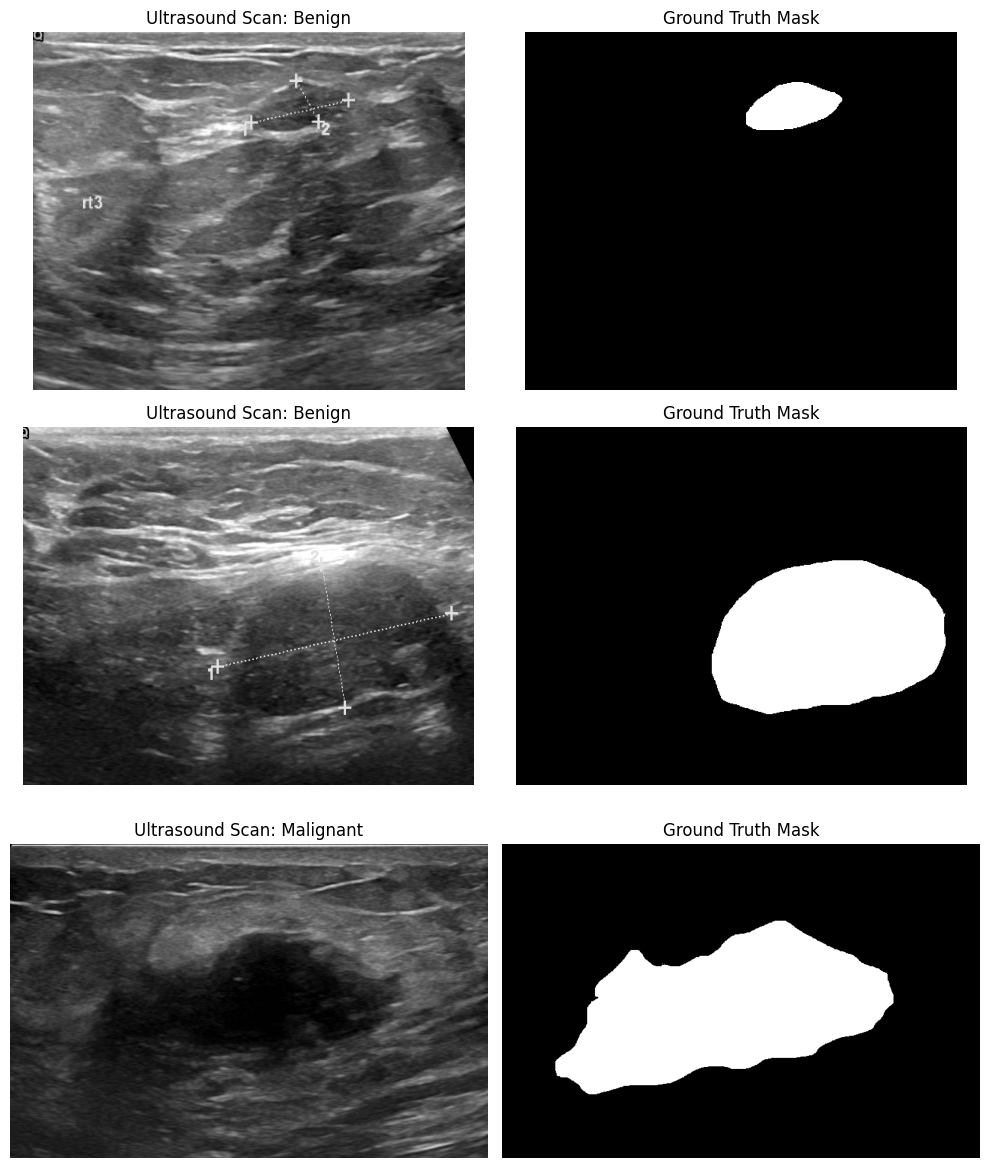

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_random_samples(X, y, labels, num_samples=3):
    """
    Displays a grid of ultrasound scans and their corresponding binary masks.
    """
    np.random.seed(42)
    indices = np.random.choice(len(X), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    
    for i, idx in enumerate(indices):
        img = np.array(X[idx])
        mask = y[idx]
        label = str(labels[idx]).capitalize()
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f"Ultrasound Scan: {label}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')   
    plt.tight_layout()
    plt.show()

plot_random_samples(X_train, y_train, train_labels, num_samples=3)

## Metrics: Measuring Precision

In medical imaging segmentation, a bounding box is insufficient. We need to evaluate the pixel-level accuracy of the tumor mapping. We use two complementary overlap metrics to score your submissions.

### 1. Primary Metric: Dice Coefficient (F1-Score)
The Dice coefficient is the gold standard for medical segmentation. It measures twice the area of overlap divided by the total number of pixels in both the prediction ($P$) and the ground truth ($G$).

$$Dice = \frac{2 \times |P \cap G|}{|P| + |G|}$$

**Why use it?** It is highly sensitive to the internal "fullness" of the mask and rewards models that capture the correct shape and size of the tumor.

### 2. Secondary Metric: Jaccard Index (Intersection over Union)
The Jaccard index is the area of intersection divided by the area of union.

$$Jaccard = \frac{|P \cap G|}{|P \cup G|}$$

**Why use it?** It is more "punishing" than the Dice coefficient for small errors. It helps break ties on the leaderboard by highlighting models with the fewest stray False Positive pixels (noise outside the tumor area).

In [30]:
import numpy as np

def dice_coefficient(y_true, y_pred, smooth=1e-7):
    """
    Compute the Dice coefficient for binary segmentation.

    Args:
        y_true (np.array): Ground truth binary mask.
        y_pred (np.array): Predicted binary mask.
        smooth (float): Small constant to avoid division by zero.
    """
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def jaccard_index(y_true, y_pred, smooth=1e-7):
    """
    Compute the Jaccard index (IoU) for binary segmentation.

    Args:
        y_true (np.array): Ground truth binary mask.
        y_pred (np.array): Predicted binary mask.
        smooth (float): Small constant to avoid division by zero.
    """
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

#dice = dice_coefficient(y_train[0], y_train[0])
#print(f"Self-alignment Dice: {dice}")

## Baseline Model: Otsu Thresholding
To establish a reference performance score on the leaderboard, we provide a simple baseline model. This approach does not use deep learning; instead, it relies on classical image processing techniques to isolate the tumor from the background.

The strategy involves two main steps:


*   Denoising: Applying a Gaussian Blur to mitigate the "speckle noise" inherent in ultrasound images.
*   Segmentation: Using Otsu’s automatic thresholding to binarize the image and extract the most prominent structures (the "blobs").

In [31]:
import cv2
import numpy as np

class Model:
    def fit(self, train_images, train_masks, train_labels=None):
        """
        The baseline model is purely statistical and does not require training.
        """
        return self

    def predict(self, test_images, sample_ids=None):
        """
        Predicts binary masks for the provided test scans.
        """
        preds = []
        for image in test_images:
            # Convert PIL image to grayscale numpy array
            img = np.array(image.convert("L"))

            # Apply Gaussian Blur to reduce noise
            blurred = cv2.GaussianBlur(img, (5, 5), 0)

            # Apply Otsu's thresholding
            _, mask = cv2.threshold(
                blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
            )

            # Ensure the output is a binary mask (0 or 1)
            binary_mask = (mask > 0).astype(np.uint8)
            preds.append(binary_mask)

        return preds

def get_model():
    return Model()

## Local Evaluation

Now that we have defined our baseline model and metrics, let's evaluate its performance. 
In this Starting Kit, you are provided with a public `test` set (including its ground truth masks in the `reference_data` folder) so you can evaluate your model locally before submitting it to CodaBench. 

In [ ]:
# 1. Initialize the baseline model
baseline_model = get_model()

# 2. "Fit" the model on the training data
baseline_model.fit(X_train, y_train, train_labels)

# 3. Generate predictions for the public test set
y_pred_test = baseline_model.predict(X_test)

# 4. Compute metrics
dice_scores = [dice_coefficient(y_test[i], y_pred_test[i]) for i in range(len(y_test))]
jaccard_scores = [jaccard_index(y_test[i], y_pred_test[i]) for i in range(len(y_test))]

print(f"Mean Dice Coefficient: {np.mean(dice_scores):.4f}")
print(f"Mean Jaccard Index:    {np.mean(jaccard_scores):.4f}")

Mean Dice Coefficient: 0.1788
Mean Jaccard Index:    0.1111


**Beat the Baseline!**

The scores above represent the performance of a simple statistical thresholding method. Your mission is to beat this score on the competition leaderboard. 

Note that the leaderboard ranks submissions primarily based on the **Dice Coefficient**. The **Jaccard Index** serves as a secondary metric to break ties, heavily penalizing stray false positive pixels.

### Submission Format

To submit your solution to the CodaBench leaderboard, you must provide a `submission.zip` file containing your model code.

1. Create a `submission.py` file.
2. Include your `Model` class with the exact `fit` and `predict` signatures shown in the baseline.
3. Include the `get_model()` function that instantiates your class.
4. Zip the file (along with any required local weights or scripts) and upload it via the CodaBench platform. Do not include the dataset in your zip archive.